In [ ]:
# TELCO CUSTOMER CHURN PREDICTION

'''
GOAL: To predict which customers are likely to churn, understanding why
and translating that into retention recommendations.
'''

In [ ]:
# END-TO-END PROJECT: EDA -> FEATURE ENGINEERING -> MODELING ->
# EXPLAINABILITY -> BUSINESS RECOMMENDATIONS

In [ ]:
# INSTALLING & IMPORTING LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score, ConfusionMatrixDisplay)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

import warnings
warnings.filterwarnings('ignore')

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

In [ ]:
# LOADING THE DATASET

In [ ]:
from google.colab import files

uploaded = files.upload() # selecting WA_Fn-UseC_-Telco-Customer-Churn.csv when prompted.
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("SHAPE: ", df.shape)
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
SHAPE:  (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# EXPLORATORY DATA ANALYSIS

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# TotalCharges is loaded as text as 11 rows have blank strings
# These are the new customers with tenure = 0 who haven't been billed yet.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Missing TotalCharges after conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [ ]:
# These are all tenure = 0 customers -> fill TotalCharges with 0 (no charges billed yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.isnull().sum().sum() # should be 0

np.int64(0)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


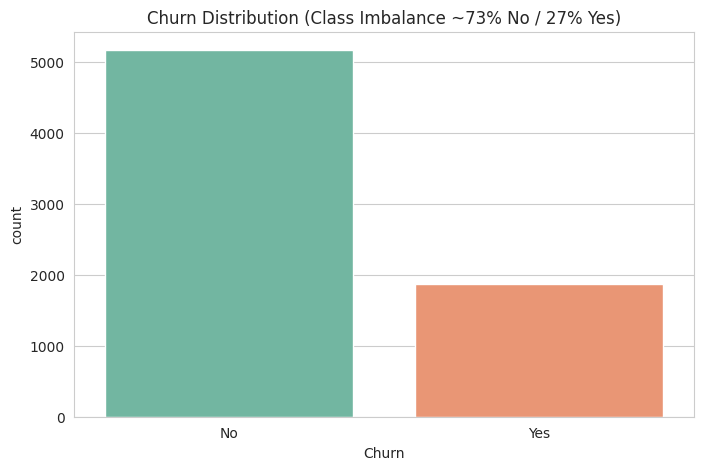

In [ ]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(2))

sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution (Class Imbalance ~73% No / 27% Yes)')
plt.show()

In [ ]:
# Churn rate by contract type -- usually the strongest predictor

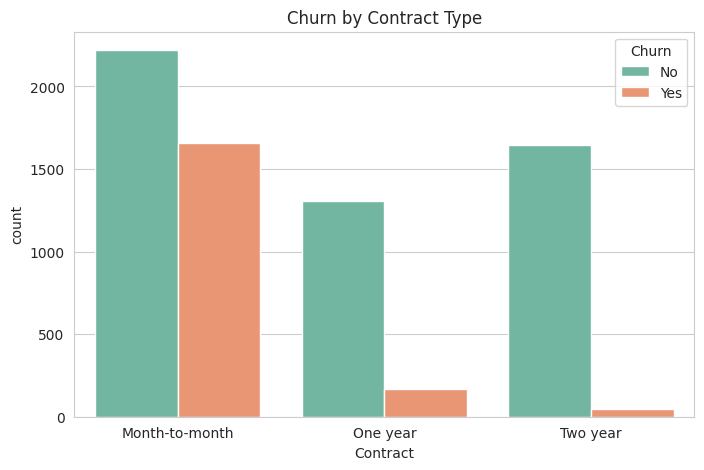

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.show()

In [ ]:
# Tenure distriution by churn

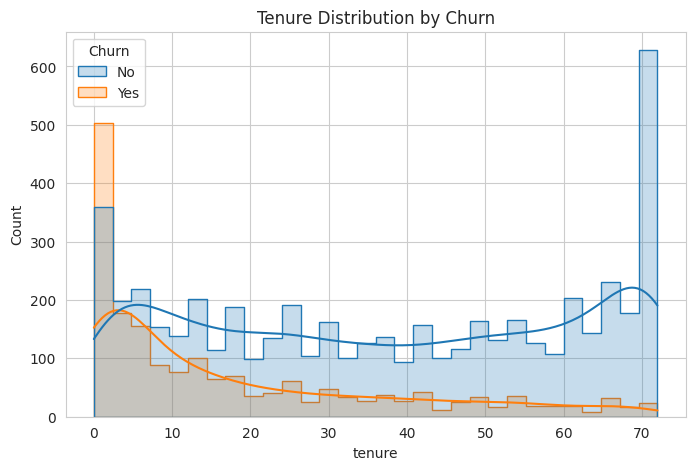

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, element='step')
plt.title('Tenure Distribution by Churn')
plt.show()

In [ ]:
# Monthly charges by churn

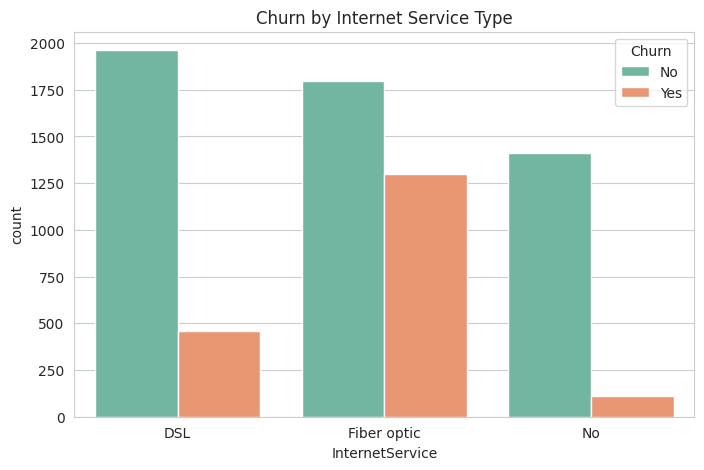

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Churn by Internet Service Type')
plt.show()

In [ ]:
# Monthly Charges by Churn

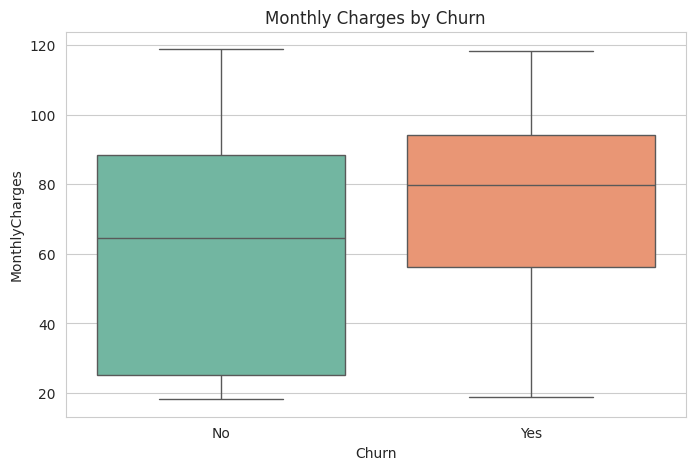

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges by Churn')
plt.show()

In [ ]:
# Correlation heatmap for numeric features

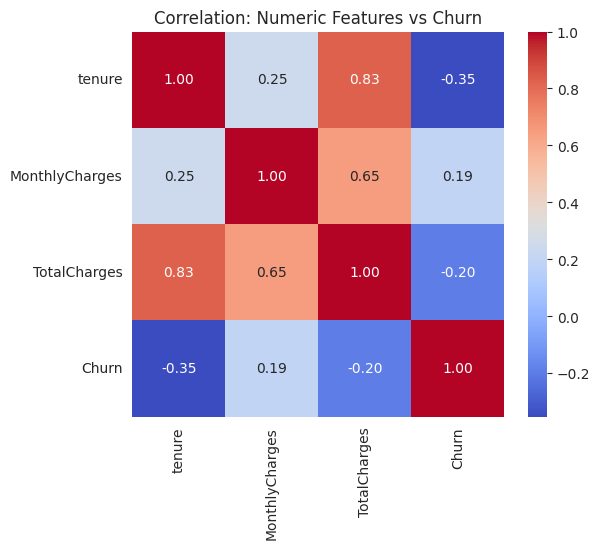

In [ ]:
plt.figure(figsize=(6, 5))
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Numeric Features vs Churn')
plt.show()

In [ ]:
# DATA CLEANING & FEATURE ENGINEERING

In [ ]:
data = df.drop(columns=['customerID']).copy()

In [ ]:
# Tenure buckets: often more interpretable than raw tenure for business reporting

In [ ]:
def tenure_bucket(t):
  if t <= 12:
    return '0-1year'
  elif t <= 24:
    return '1-2year'
  elif t <= 48:
    return '2-4year'
  else:
    return '4year+'

In [ ]:
data['tenure_group'] = data['tenure'].apply(tenure_bucket)

In [ ]:
# Target encoding

In [ ]:
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

In [ ]:
# Identify categorical columns (object dtype)

In [ ]:
cat_cols = data.select_dtypes(include='object').columns.tolist()
print("Categorical Columns: ", cat_cols)

Categorical Columns:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [ ]:
# One-hot encode categorical variables

In [ ]:
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)
print("Shape after encoding: ", data_encoded.shape)
data_encoded.head()

Shape after encoding:  (7043, 34)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2year,tenure_group_2-4year,tenure_group_4year+
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False


In [ ]:
X = data_encoded.drop(columns=['Churn'])
Y = data_encoded['Churn']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=RANDOM_STATE)
print("Train Shape:", X_train.shape, "Test Shape:", X_test.shape)
print("Train Churn Rate:", Y_train.mean().round(3), "Test Churn Rate:", Y_test.mean().round(3))

Train Shape: (5634, 33) Test Shape: (1409, 33)
Train Churn Rate: 0.265 Test Churn Rate: 0.265


In [ ]:
# Handle class imbalance with SMOTE (only on training data, never on test data)

In [ ]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)
print("BEFORE SMOTE:", Y_train.value_counts().to_dict())
print("AFTER SMOTE:", Y_train_resampled.value_counts().to_dict())

BEFORE SMOTE: {0: 4139, 1: 1495}
AFTER SMOTE: {0: 4139, 1: 4139}


In [ ]:
# MODEL BUILDING & COMPARISON

In [ ]:
results = {}

def evaluate_model(name, model, X_te, Y_te):
  Y_pred = model.predict(X_te)
  Y_proba = model.predict_proba(X_te)[:, 1]
  f1 = f1_score(Y_te, Y_pred)
  auc = roc_auc_score(Y_te, Y_proba)
  results[name] = {'f1': f1, 'roc_auc': auc}
  print(f"-------- {name} --------")
  print(classification_report(Y_te, Y_pred, target_names=['No Churn', 'Churn']))
  print(f"ROC-AUC: {auc:.4f}\n")
  return Y_pred, Y_proba

In [ ]:
# Logistic Regression

In [ ]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train_resampled)
X_test_scaled = scalar.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, Y_train_resampled)
lr_pred, lr_proba = evaluate_model("LOGISTIC REGRESSION", log_reg, X_test_scaled, Y_test)

-------- LOGISTIC REGRESSION --------
              precision    recall  f1-score   support

    No Churn       0.85      0.82      0.83      1035
       Churn       0.55      0.61      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409

ROC-AUC: 0.8145



In [ ]:
# Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE)
rf.fit(X_train_resampled, Y_train_resampled)
rf_pred, rf_proba = evaluate_model("RANDOM FOREST", rf, X_test, Y_test)

-------- RANDOM FOREST --------
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.69      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409

ROC-AUC: 0.8351



In [ ]:
# XGBoost

In [ ]:
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_model.fit(X_train_resampled, Y_train_resampled)
xgb_pred, xgb_proba = evaluate_model("XGBoost", xgb_model, X_test, Y_test)

-------- XGBoost --------
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.84      1035
       Churn       0.56      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC: 0.8241



In [ ]:
# Comparing all models

                           f1   roc_auc
RANDOM FOREST        0.610651  0.835115
XGBoost              0.589581  0.824149
LOGISTIC REGRESSION  0.579345  0.814467


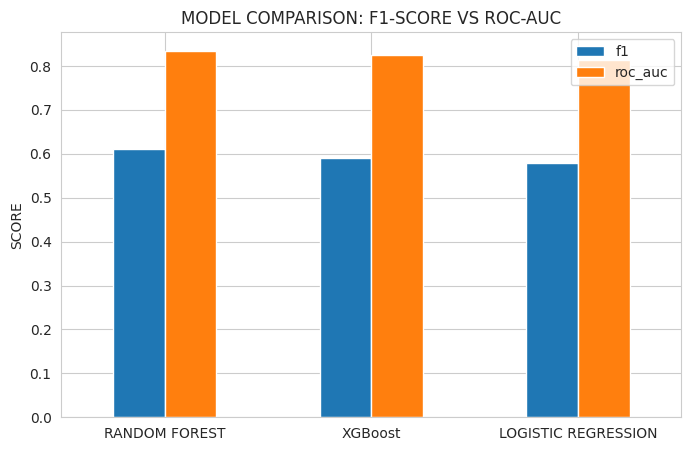

In [ ]:
results_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
print(results_df)

results_df.plot(kind='bar', figsize=(8, 5))
plt.title('MODEL COMPARISON: F1-SCORE VS ROC-AUC')
plt.ylabel('SCORE')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# ROC curves for all models

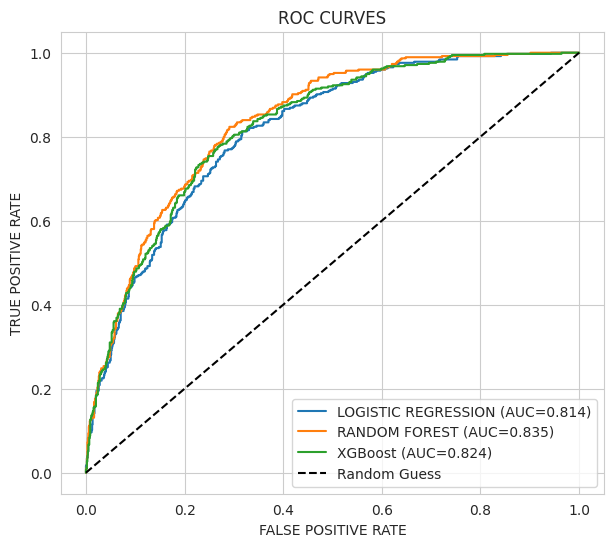

In [ ]:
plt.figure(figsize=(7, 6))
for name, proba in [('LOGISTIC REGRESSION', lr_proba), ('RANDOM FOREST', rf_proba), ('XGBoost', xgb_proba)]:
  fpr, tpr, _ = roc_curve(Y_test, proba)
  auc = roc_auc_score(Y_test, proba)
  plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('FALSE POSITIVE RATE')
plt.ylabel('TRUE POSITIVE RATE')
plt.title('ROC CURVES')
plt.legend()
plt.show()

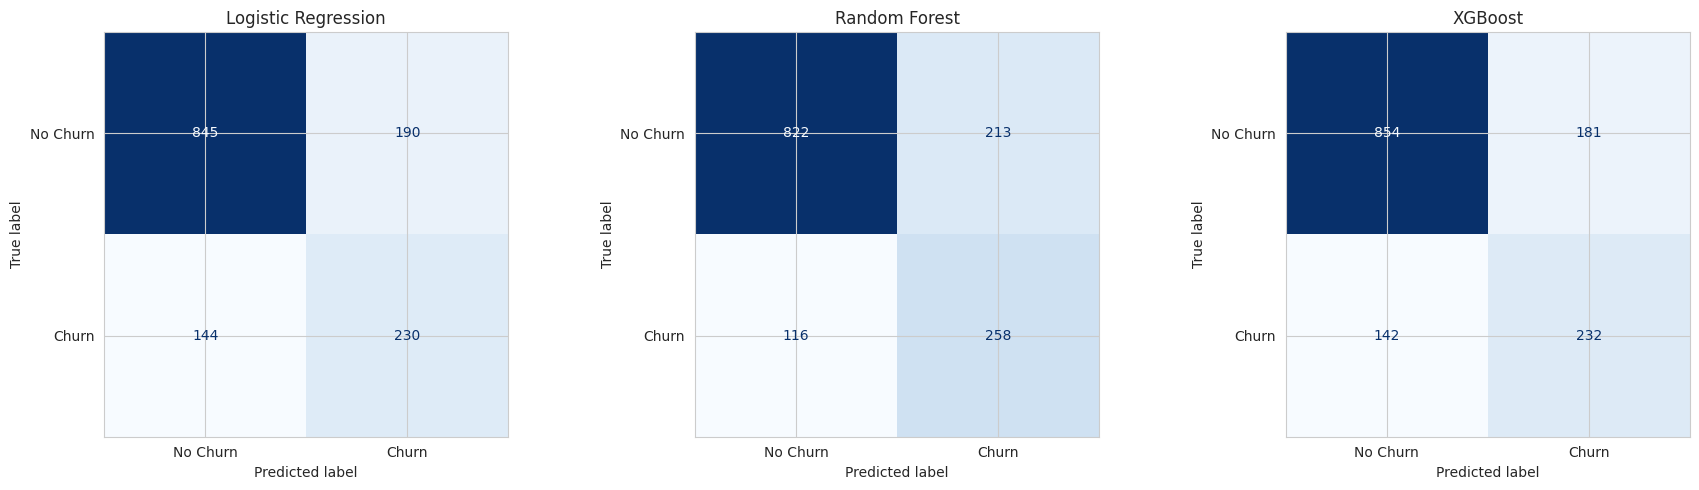

In [ ]:
# Confusion matrices for all three models, side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred)
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(Y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix for best model (assuming XGBoost; adjusting if another model wins)

BEST MODEL BY ROC-AUC: RANDOM FOREST


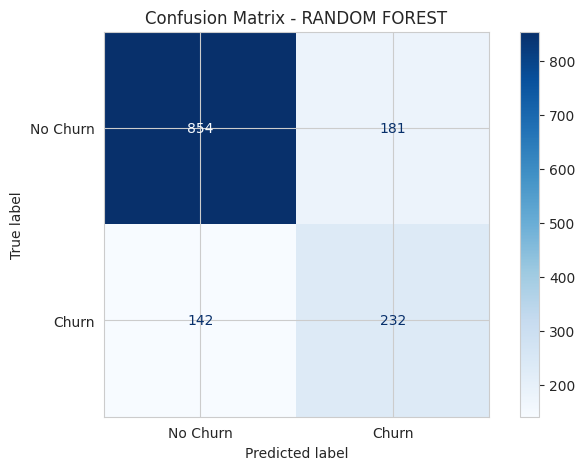

In [ ]:
best_model_name = results_df.index[0]
print("BEST MODEL BY ROC-AUC:", best_model_name)

cm = confusion_matrix(Y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [ ]:
# EXPLAINABILITY WITH SHAP

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

In [ ]:
# Global feature importance

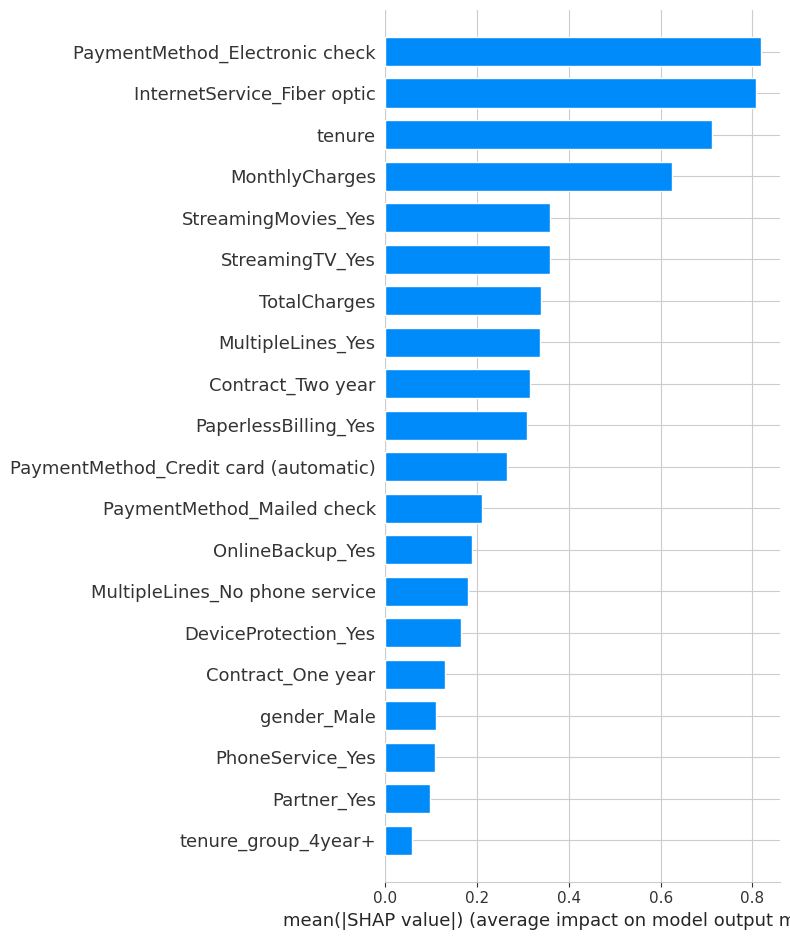

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

In [ ]:
# Detailed summary plot: direction and magnitude of each feature's effect

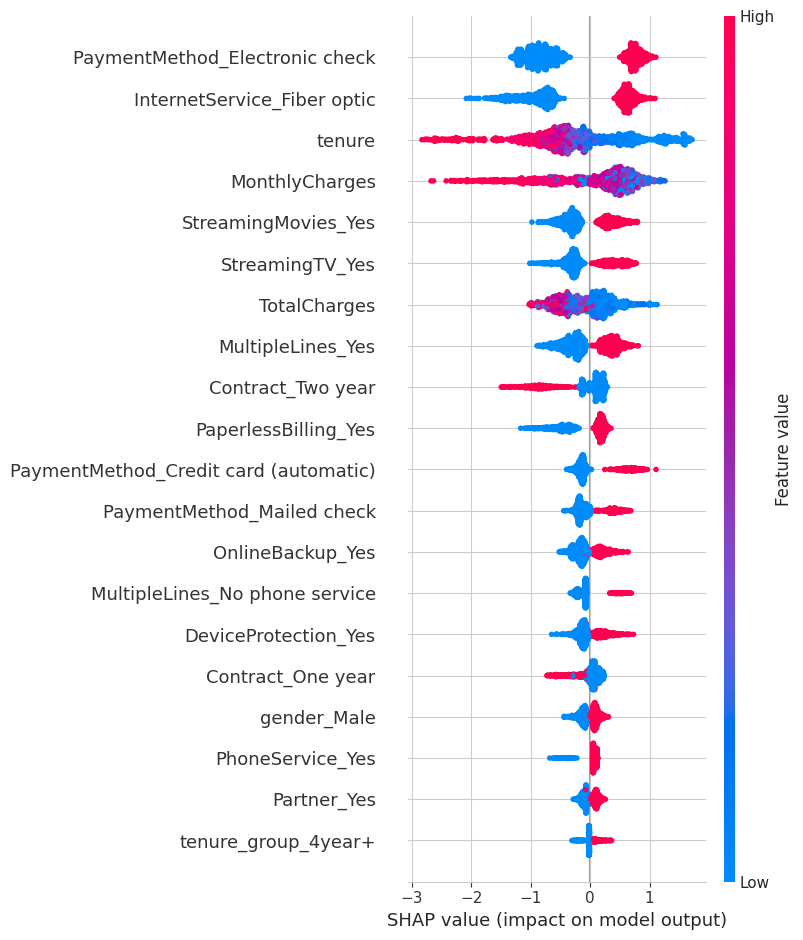

In [ ]:
shap.summary_plot(shap_values, X_test, show=True)

In [ ]:
# Example: explain a single prediction (first customer in test set who churned)

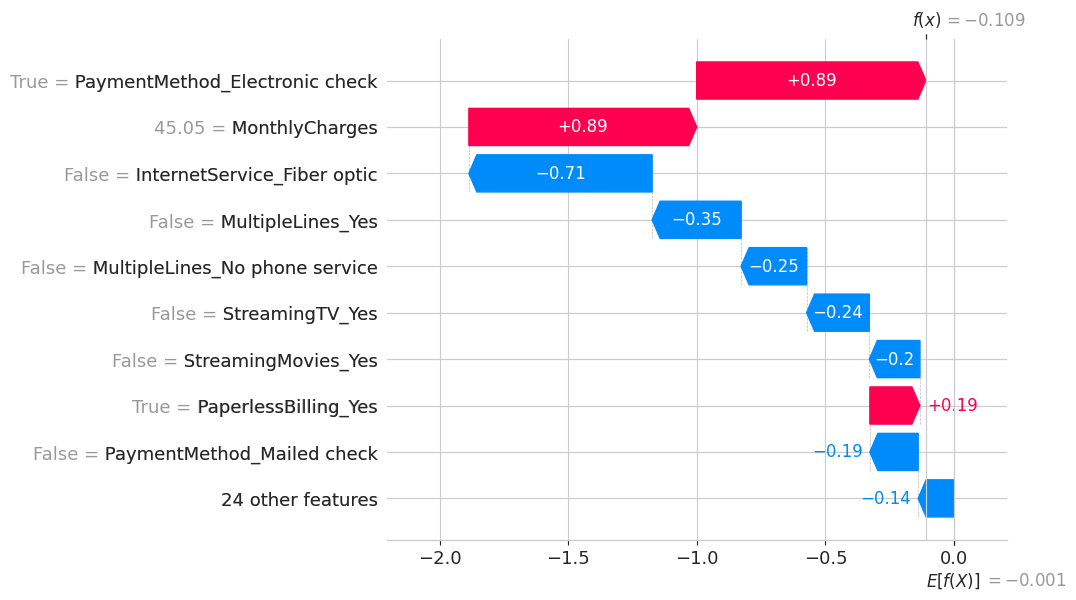

In [ ]:
churn_idx = Y_test[Y_test == 1].index[0]
row_position = X_test.index.get_loc(churn_idx)

shap.plots.waterfall(shap.Explanation(values=shap_values[row_position], base_values=explainer.expected_value, data=X_test.iloc[row_position], feature_names=X_test.columns))